In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Video One
video_path = '../data/GH017914.MP4'
output_video_path = '../output/GH017914_flow_overlay_1.mp4'

start_sec = 36.0
end_sec   = 68.0

In [79]:
# Hanna 2
video_path = 'C:\\Users\\user\\Desktop\\MotionReconstruction\\GH017914.mp4'    
output_video_path = 'C:\\Users\\user\\Desktop\\MotionReconstruction\\GH017914_flow_overlay_2.mp4'

start_sec = 78.0
end_sec   = 102.0

In [80]:
# Niki 1
video_path = 'C:\\Users\\user\\Desktop\\MotionReconstruction\\GH017916.mp4'    
output_video_path = 'C:\\Users\\user\\Desktop\\MotionReconstruction\\GH017916_flow_overlay_1.mp4'

start_sec = 14.0
end_sec   = 39.0

In [86]:
# Niki 2
video_path = 'C:\\Users\\user\\Desktop\\MotionReconstruction\\GH017916.mp4'    
output_video_path = 'C:\\Users\\user\\Desktop\\MotionReconstruction\\GH017916_flow_overlay_2.mp4'

start_sec = 46.0
end_sec   = 70.0

In [6]:
# IMPUT PARAMETERS

# ROI: (x, y, w, h) --> This creates a region of interest
roi = (750, 350, 500, 400)

# Pixel -> degree
px_to_deg = 0.0616  # deg / pixel

# Percentile-based outlier cutting
p_low = 2    # lower outliers
p_high = 98   # upper outliers

# Low-pass filter-based smoothing
tau_hp = 1.0  # [s]

In [8]:
# HELPERS

#Creates the region of interest
def crop_roi(img, roi):
    x, y, w, h = roi
    return img[y:y+h, x:x+w]

#Draws the green arrow related to the pixels
def draw_flow_arrows(frame, flow, roi, step, scale, min_mag):
    x0, y0, w, h = roi
    H, W = flow.shape[:2]

    for y in range(0, H, step):
        for x in range(0, W, step):
            u, v = flow[y, x]
            mag = np.hypot(u, v)
            if mag < min_mag:
                continue

            p1 = (x0 + x, y0 + y)
            p2 = (int(x0 + x + u * scale), int(y0 + y + v * scale))
            cv2.arrowedLine(frame, p1, p2, (0, 255, 0), 1, tipLength=0.3)

    cv2.rectangle(frame, (x0, y0), (x0 + w, y0 + h), (255, 200, 0), 2)
    return frame



def high_pass_filter(signal, fps, tau_sec):

    dt = 1.0 / fps
    alpha = tau_sec / (tau_sec + dt)

    y = np.zeros_like(signal)
    for i in range(1, len(signal)):
        y[i] = alpha * (y[i-1] + signal[i] - signal[i-1])

    return y

In [9]:
# VIDEO

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError("Video cannot be opened")

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

start_frame = int(start_sec * fps)
end_frame   = int(end_sec * fps)
end_frame   = min(end_frame, total_frames - 1)

cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame) #Moves the pointer
ret, prev_frame = cap.read()
if not ret:
    raise RuntimeError("Frames cannot be read")

prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
prev_roi = crop_roi(prev_gray, roi)

# Video writer
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(
    output_video_path,
    fourcc,
    fps,
    (prev_frame.shape[1], prev_frame.shape[0])
)

# OPTICAL FLOW

timestamps = []
yaw_angle = []
pitch_angle = []

yaw = 0.0
pitch = 0.0

frame_idx = start_frame

draw_step = 18
draw_scale = 1.0
min_mag_draw = 0.3

while frame_idx < end_frame:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    curr_roi = crop_roi(gray, roi)

    flow = cv2.calcOpticalFlowFarneback(
        prev_roi, curr_roi, None,
        pyr_scale=0.5,
        levels=3,
        winsize=15,
        iterations=3,
        poly_n=5,
        poly_sigma=1.2,
        flags=0
    )

    u = flow[..., 0].reshape(-1)
    v = flow[..., 1].reshape(-1)
    mag = np.hypot(u, v)

    # Percentile-based outlier cutting

    lo = np.percentile(mag, p_low)
    hi = np.percentile(mag, p_high)

    mask = (mag >= lo) & (mag <= hi)

    u_f = u[mask]
    v_f = v[mask]

    u_mean = float(np.mean(u_f))
    v_mean = float(np.mean(v_f))


    # Yaw and Pitch angle integration
    yaw   += u_mean * px_to_deg
    pitch += v_mean * px_to_deg

    t = frame_idx / fps

    timestamps.append(t)
    yaw_angle.append(yaw)
    pitch_angle.append(pitch)

    # Overlay video
    overlay = draw_flow_arrows(
        frame.copy(),
        flow,
        roi,
        draw_step,
        draw_scale,
        min_mag_draw
    )

    cv2.putText(
        overlay,
        f"t={t:.2f}s | frame={frame_idx:+.2f}",
        (20, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2
    )

    out.write(overlay)

    prev_roi = curr_roi
    frame_idx += 1

cap.release()
out.release()

timestamps = np.array(timestamps)
yaw_angle = np.array(yaw_angle)
pitch_angle = np.array(pitch_angle)

In [10]:
# HIGH-PASS FILTER (DRIFT REMOVAL)

yaw_hp = high_pass_filter(yaw_angle, fps, tau_hp)
pitch_hp = high_pass_filter(pitch_angle, fps, tau_hp)

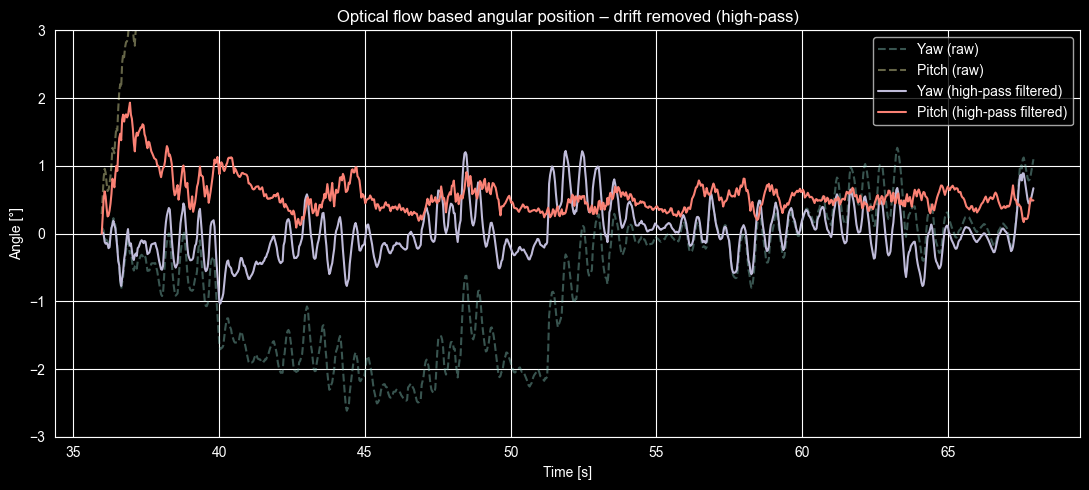

In [13]:
# PLOT OF RESULTS

plt.figure(figsize=(11, 5))

plt.plot(timestamps, yaw_angle, "--", alpha=0.4, label="Yaw (raw)")
plt.plot(timestamps, pitch_angle, "--", alpha=0.4, label="Pitch (raw)")

plt.plot(timestamps, yaw_hp, label="Yaw (high-pass filtered)")
plt.plot(timestamps, pitch_hp, label="Pitch (high-pass filtered)")

plt.xlabel("Time [s]")
plt.ylabel("Angle [°]")
plt.title("Optical flow based angular position – drift removed (high-pass)")
plt.grid(True)
plt.legend()
plt.ylim(-3, 3)
plt.tight_layout()
plt.show()